In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re 
import glob
from matplotlib.colors import ListedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
from matplotlib import colors
import matplotlib.ticker as ticker

In [2]:
# Read in data
cells = pd.read_csv('../data/myeloid_panel_umap_patient_updated.csv', index_col=0)
cells.head()

,209Bi_CD45,Center,161Dy_CD274_PDL1,162Dy_CD80,Event_length,157Gd,113In_CD45,191Ir_DNA1,193Ir_DNA2,175Lu_STAT1_PE,...,173Yb_CD47_Biotin_asinh_coarseAlign_fineAlign,174Yb_HLA-DR_asinh_coarseAlign_fineAlign,176Yb_CD56_asinh_coarseAlign_fineAlign,Alignment_MC_fineAlign,FlowSOM_cluster,FlowSOM_metacluster,FlowSOM_cluster.1,FlowSOM_metacluster.1,UMAP_X,UMAP_Y
1,0.00000,0.000,3.88961,0.0,22,0.00000,0.0,158.923,307.365,16.45780,...,4.771649,1.059669,0.556633,2,143,24,6,2,-3.129287,6.578265
2,0.00000,949.553,2.01143,0.0,20,0.00000,0.0,287.998,537.970,27.61740,...,4.522643,2.077372,0.136398,6,27,12,131,10,-4.816134,-4.346446
3,1.17233,723.309,2.35961,0.0,19,0.00000,0.0,169.809,299.578,5.22007,...,5.787666,0.783705,0.062180,7,19,9,88,9,-0.664257,-5.016717
4,0.00000,868.160,1.08257,0.0,21,2.85382,0.0,188.745,349.081,13.24680,...,5.552658,2.958660,0.136398,6,41,12,103,10,-4.368270,-4.707629
5,4.20128,0.000,0.00000,0.0,17,0.00000,0.0,109.358,222.585,3.00359,...,5.424986,0.603684,0.820364,7,19,9,88,9,-0.691456,-4.948173


In [3]:
# Delete spare progression sample (there was a second later measurement which was associated with progression)
# Delete sample 61290 006 as the patient went off trial due to participant preference
print(cells.shape)
cells = cells.loc[cells['FileName'] != 'P02_SPD_Myeloid_Panel',:]
cells = cells.loc[~cells['FileName'].str.contains('P26'),:]
# # Delete the following samples as they have only a single measurement
cells = cells.loc[~cells['FileName'].str.contains('P27'),:]
cells = cells.loc[~cells['FileName'].str.contains('P15'),:]
cells['FileName'] = cells['FileName'].str.replace('P02_SPD_2_Myeloid_Panel', 'P02_SPD_Myeloid_Panel')
print(cells.shape)

(295000, 69)
(282500, 69)


In [4]:
# Read in clustering results which were updated 2025_05_20
cell_type = pd.read_csv('../data/myeloid_panel_clusters_2025_05_20.csv', index_col = 0)
cell_type_dict = dict(zip(cell_type.index, cell_type['cell_type']))

del cell_type

In [5]:
# Map the flowsom clustering to the actual cell type
cells['cell_type'] = cells['FlowSOM_metacluster'].map(cell_type_dict)
cells.head(10)

,209Bi_CD45,Center,161Dy_CD274_PDL1,162Dy_CD80,Event_length,157Gd,113In_CD45,191Ir_DNA1,193Ir_DNA2,175Lu_STAT1_PE,...,174Yb_HLA-DR_asinh_coarseAlign_fineAlign,176Yb_CD56_asinh_coarseAlign_fineAlign,Alignment_MC_fineAlign,FlowSOM_cluster,FlowSOM_metacluster,FlowSOM_cluster.1,FlowSOM_metacluster.1,UMAP_X,UMAP_Y,cell_type
1,0.00000,0.000,3.88961,0.00000,22,0.00000,0.0000,158.923,307.365,16.45780,...,1.059669,0.556633,2,143,24,6,2,-3.129287,6.578265,T_Cell
2,0.00000,949.553,2.01143,0.00000,20,0.00000,0.0000,287.998,537.970,27.61740,...,2.077372,0.136398,6,27,12,131,10,-4.816134,-4.346446,Myeloid
3,1.17233,723.309,2.35961,0.00000,19,0.00000,0.0000,169.809,299.578,5.22007,...,0.783705,0.062180,7,19,9,88,9,-0.664257,-5.016717,Aberrant_2
4,0.00000,868.160,1.08257,0.00000,21,2.85382,0.0000,188.745,349.081,13.24680,...,2.958660,0.136398,6,41,12,103,10,-4.368270,-4.707629,Myeloid
5,4.20128,0.000,0.00000,0.00000,17,0.00000,0.0000,109.358,222.585,3.00359,...,0.603684,0.820364,7,19,9,88,9,-0.691456,-4.948173,Aberrant_2
6,1.69345,1370.120,0.00000,3.18531,25,0.00000,0.0000,352.852,664.407,4.66222,...,1.512360,1.295581,1,102,25,31,4,3.713614,-1.824399,Cytotoxic NK
7,0.00000,922.951,0.00000,0.00000,22,0.00000,0.0000,214.946,463.390,13.91180,...,3.094261,0.810377,1,30,1,113,6,0.941047,-6.431448,HSPCs
8,1.50017,451.994,5.03035,0.00000,12,0.00000,0.0000,104.103,229.571,3.24079,...,1.515813,0.050097,2,141,24,22,2,-4.179858,8.285614,T_Cell
9,0.00000,618.370,14.85530,0.00000,15,0.00000,0.0000,170.424,329.395,6.04834,...,0.201496,0.056456,1,15,1,71,6,2.133274,-6.109665,HSPCs
10,5.16860,895.184,0.00000,0.00000,22,0.00000,1.4613,112.415,252.563,12.00360,...,2.082606,5.880555,3,193,37,154,15,9.600781,-2.942843,Cytotoxic NK


In [6]:
# Fix the 'Timepoint' column in the dataframe so that I can merge it with a data sheet 
#that Julie has provided to me
cells['Timepoint'] = cells['Timepoint'].str.replace('_Control', '')
cells['Timepoint'] = cells['Timepoint'].str.replace('SPD', 'Progression')
cells['Timepoint'] = cells['Timepoint'].str.replace('_', '')
cells['Patient_timepoint'] = cells['Patient_ID'] + '_' + cells['Timepoint']
cells['Patient_timepoint'] =  cells['Patient_timepoint'].astype(str)
cells

,209Bi_CD45,Center,161Dy_CD274_PDL1,162Dy_CD80,Event_length,157Gd,113In_CD45,191Ir_DNA1,193Ir_DNA2,175Lu_STAT1_PE,...,176Yb_CD56_asinh_coarseAlign_fineAlign,Alignment_MC_fineAlign,FlowSOM_cluster,FlowSOM_metacluster,FlowSOM_cluster.1,FlowSOM_metacluster.1,UMAP_X,UMAP_Y,cell_type,Patient_timepoint
1,0.00000,0.000,3.88961,0.0,22,0.00000,0.0,158.9230,307.365,16.45780,...,0.556633,2,143,24,6,2,-3.129287,6.578265,T_Cell,P08_C1D8
2,0.00000,949.553,2.01143,0.0,20,0.00000,0.0,287.9980,537.970,27.61740,...,0.136398,6,27,12,131,10,-4.816134,-4.346446,Myeloid,P08_C1D8
3,1.17233,723.309,2.35961,0.0,19,0.00000,0.0,169.8090,299.578,5.22007,...,0.062180,7,19,9,88,9,-0.664257,-5.016717,Aberrant_2,P08_C1D8
4,0.00000,868.160,1.08257,0.0,21,2.85382,0.0,188.7450,349.081,13.24680,...,0.136398,6,41,12,103,10,-4.368270,-4.707629,Myeloid,P08_C1D8
5,4.20128,0.000,0.00000,0.0,17,0.00000,0.0,109.3580,222.585,3.00359,...,0.820364,7,19,9,88,9,-0.691456,-4.948173,Aberrant_2,P08_C1D8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294996,415.45300,424.830,1.09663,0.0,12,0.00000,0.0,55.0982,134.752,21.38940,...,0.771934,2,131,24,80,2,1.062799,4.495797,T_Cell,Control_11_Healthy
294997,129.69000,641.429,1.07178,0.0,19,0.00000,0.0,130.9960,151.444,14.40410,...,0.183470,2,185,24,13,2,-2.637055,9.658604,T_Cell,Control_11_Healthy
294998,178.62400,472.424,0.00000,0.0,13,0.00000,0.0,81.8000,107.560,0.00000,...,3.338881,3,195,37,194,15,9.750433,-0.666852,Cytotoxic NK,Control_11_Healthy
294999,390.07500,579.636,0.00000,0.0,15,0.00000,0.0,67.3443,108.050,4.24083,...,0.324357,2,127,24,7,2,-4.734169,7.355649,T_Cell,Control_11_Healthy


In [7]:
# Read in patient info sheet (this was sent to me by Julie on 2024_01_17)
patient_info = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx')
patient_info = patient_info.loc[~patient_info['Outcome_C6_revised_Vid'].isna(), :]
patient_info['PID'] = patient_info['PID'].astype(str)

# Create dictionaries so that I can add information to the dataframe such as 
# diagnosis and clinical outcomes
diagnosis_dx = dict(zip(patient_info['PID'], patient_info['Diagnosis']))
outcome_C6_dx = dict(zip(patient_info['PID'], patient_info['Outcome_C6_revised_Vid']))
outcome_C12_dx = dict(zip(patient_info['PID'], patient_info['Outcome_C12_CC486']))


In [8]:
# Use the dictionaries to add clinical outcomes to the dataframe
cells['diagnosis'] = cells['Patient_ID'].map(diagnosis_dx)
cells['outcome_6'] = cells['Patient_ID'].map(outcome_C6_dx)
cells['outcome_12'] = cells['Patient_ID'].map(outcome_C12_dx)

# Update the clinical outcomes and diagnosis columns to reflect that there are healthy samples in the sample set
diagnosis = ['Healthy' if 'Healthy' in x else y for x, y in zip(cells['Patient_ID'], cells['diagnosis'])]
        
outcome_6 = ['Healthy' if 'Healthy' in x else y for x, y in zip(cells['Patient_ID'], cells['outcome_6'])]

outcome_12 = ['Healthy' if 'Healthy' in x else y for x, y in zip(cells['Patient_ID'], cells['outcome_12'])]

cells['diagnosis'] = diagnosis
cells['outcome_6'] = outcome_6
cells['outcome_12'] = outcome_12 


In [9]:
# Create a list so that I can delete the samples where I acquired a C7D22 but the patient dropped out for
# reasons unrelated to the disease or treatment note that these patients have an NA in the outcome_12 column

time_to_keep = ['non-responder_2', 'responder_1', 'Healthy']

to_del = [x for x, y in zip(cells['Patient_timepoint'], cells['outcome_12']) 
          if 'C7D22' in x and y not in time_to_keep]

print(cells.shape)
cells1 = cells.loc[~cells['Patient_timepoint'].isin(to_del), :]
print(cells1.shape)

del to_del

(282500, 74)
(277500, 74)


In [10]:
# Add a column called best response which details the best clinical response of each patient
# if a patient is called a responder at any timepont they are called a responder even if they eventually progress
best_response = [
    'responder_1' if x == 'responder_1' or y == 'responder_1'
    else 'Healthy' if y == 'Healthy'
    else 'non-responder_2'
    for x, y in zip(cells1['outcome_6'], cells1['outcome_12'])
]

cells1['best_response'] = best_response
cells1.head()

/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_6429/2506265584.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cells1['best_response'] = best_response


,209Bi_CD45,Center,161Dy_CD274_PDL1,162Dy_CD80,Event_length,157Gd,113In_CD45,191Ir_DNA1,193Ir_DNA2,175Lu_STAT1_PE,...,FlowSOM_cluster.1,FlowSOM_metacluster.1,UMAP_X,UMAP_Y,cell_type,Patient_timepoint,diagnosis,outcome_6,outcome_12,best_response
1,0.00000,0.000,3.88961,0.0,22,0.00000,0.0,158.923,307.365,16.45780,...,6,2,-3.129287,6.578265,T_Cell,P08_C1D8,MDS,non-responder_2,non-responder_2,non-responder_2
2,0.00000,949.553,2.01143,0.0,20,0.00000,0.0,287.998,537.970,27.61740,...,131,10,-4.816134,-4.346446,Myeloid,P08_C1D8,MDS,non-responder_2,non-responder_2,non-responder_2
3,1.17233,723.309,2.35961,0.0,19,0.00000,0.0,169.809,299.578,5.22007,...,88,9,-0.664257,-5.016717,Aberrant_2,P08_C1D8,MDS,non-responder_2,non-responder_2,non-responder_2
4,0.00000,868.160,1.08257,0.0,21,2.85382,0.0,188.745,349.081,13.24680,...,103,10,-4.368270,-4.707629,Myeloid,P08_C1D8,MDS,non-responder_2,non-responder_2,non-responder_2
5,4.20128,0.000,0.00000,0.0,17,0.00000,0.0,109.358,222.585,3.00359,...,88,9,-0.691456,-4.948173,Aberrant_2,P08_C1D8,MDS,non-responder_2,non-responder_2,non-responder_2


In [11]:
# Read in a sheet which details the cluster, color of each cluster and order of the plotting
order = pd.read_excel('../data/cluster_color_and_order.xlsx')
order = order.sort_values('Order')
order_dict = dict(zip(order['Cluster'], order['Order']))
color_dict = dict(zip(order['Cluster'], order['color']))

# Create a dictionary to specify the location of the numebrs to specify cluster identity in the UMAP plots
text_dict ={}
for label, x, y in zip(order['Order'], order['x_pos'], order['y_pos']):
    dict1 = {}
    dict1['xpos'] = x
    dict1['ypos'] = y
    text_dict[label] = dict1

In [12]:
# Print the number of samples in each outcome group at a specific timepoint
tp = ['C7D1', 'C7D22']
n_r = [] 
r = [] 
for x in cells1['Patient_ID'].unique():
    a = cells1.loc[(cells1['Patient_ID'] == x) & cells1['Timepoint'].isin(tp), :] 
    if 'non-responder_2' in a['best_response'].values:
        n_r.append(x) 
    elif 'responder_1' in a['best_response'].values:
        r.append(x)
print(len(list(set(r))), len(list(set(n_r))))

15 5


/var/folders/8n/0q8k5j814xj4bcjqhcvny6p80000gn/T/ipykernel_6429/1138860054.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


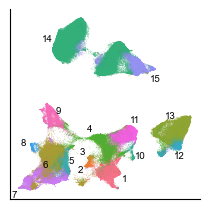

In [13]:
# Make figure without a legend
plt.rcParams["font.family"] = "Arial"
plt.rcParams['svg.fonttype'] = 'none' # export font as editable text
plt.rcParams['pdf.fonttype'] = 'truetype' # export font as editable text

#color_dict = {'non-responder_2' : '#fe9003', 'responder_1': '#115284', 'Healthy': 'grey'}
plt.rcParams.update({'mathtext.default':  'regular' })

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (2.2, 2.2), constrained_layout=True)



ax.scatter(x = cells1['UMAP_X'], y = cells1['UMAP_Y'], s = 0.1, c = cells1['cell_type'].map(color_dict), 
             linewidth = 0, rasterized=True)

for label, value in text_dict.items():
    ax.text(x=value['xpos'], y=value['ypos'], s=str(label), fontsize=7)
    

ax.legend([], frameon = False) 

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('', fontsize = 7)
ax.set_ylabel('',  fontsize = 7)
ax.set_yticks(ticks = [], labels = '')
ax.set_xticks(ticks = [], labels = '')
ax.tick_params(labelsize = 7)


plt.tight_layout()
# fig.savefig('../graphs/layout_version_7_1.png', dpi = 600)
#fig.savefig('../graphs/layout_version_7_1.pdf', bbox_inches = 'tight', pad_inches=0.01,  dpi = 600)


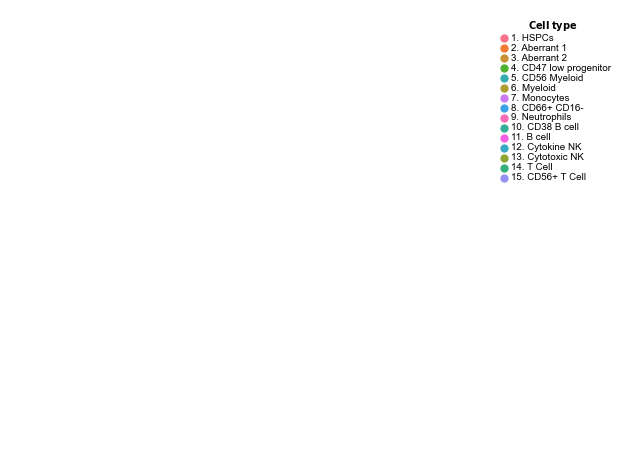

In [14]:
plt.rcParams["font.family"] = "Arial"
plt.rcParams['svg.fonttype'] = 'none' # export font as editable text
plt.rcParams['pdf.fonttype'] = 'truetype' # export font as editable text
handles3 = []
f3, a3 = plt.subplots()
for lab in order_dict.keys():
    line = a3.scatter([0],[0], label=lab, color=color_dict[lab], marker = 'o', s = 50, alpha = 1)
    handles3.append(line)    
plt.close(f3)
fig, ax = plt.subplots()
labels = color_dict.keys()
labels1 = []
for x, i in enumerate(labels):
    i = i.replace('_', ' ')
    i = i.replace(' pos ', '+ ')
    i = i.replace(' neg', '-')
    labels1.append(str(x +1) +'. ' + i)
ax.legend(handles = handles3, labels = labels1,
          title = "$\\bf{Cell}$" + ' ' + "$\\bf{type}$", bbox_to_anchor = (1.0, 1.0),
           ncol = 1, columnspacing = 0.8, handletextpad = -0.3, labelspacing = 0.1, fontsize = 7, frameon = False,
           title_fontsize = 7, markerscale = 0.7)

ax.axis('off')

plt.tight_layout()
# fig.savefig('../graphs/cell_type_legend.png', dpi = 1200, pad_inches=0.1)
#fig.savefig('../graphs/cell_type_legend_v1.pdf', bbox_inches = 'tight', pad_inches=0.01,  dpi = 1200)

In [15]:
# Create a dictionary to add text to certain clusters (not all in order)
order1 = order.loc[order['to_add_to_responder_non_responder_umap'] == 'Yes', :]
# Create a dictionary to specify the location of the numebrs to specify cluster identity in the UMAP plots
responder_text_dict ={}
for label, x, y in zip(order1['Order'], order1['x_pos'], order1['y_pos']):
    dict1 = {}
    dict1['xpos'] = x
    dict1['ypos'] = y
    responder_text_dict[label] = dict1  

In [16]:
#
patient_tp = []
for x in cells1['Patient_ID'].unique():
    x1 = cells1.loc[cells1['Patient_ID'] == x, :]
    if ('C7D22' in x1['Timepoint'].to_list()) & ('C7D1' not in x1['Timepoint'].to_list()):
        patient_tp.append(str(x) + '_C7D22')

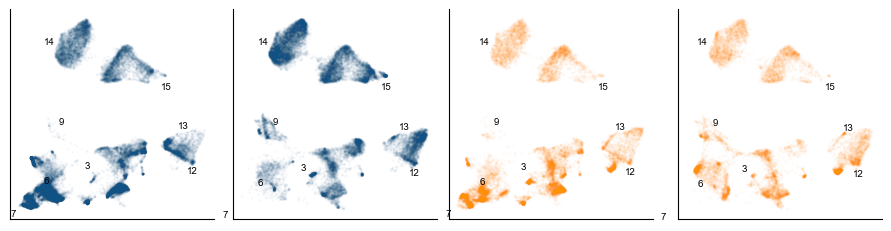

In [17]:
# Setup 
plt.rcParams["font.family"] = "Arial"
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 'truetype'
plt.rcParams.update({'mathtext.default': 'regular'})

color_dict = {'non-responder_2': '#fe9003', 'responder_1': '#115284', 'Healthy': 'grey'}

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(8.8, 2.2), constrained_layout=True)

# Define plot configurations
plot_configs = [
    ('responder_1', 'C1D1'),
    ('responder_1', 'C7D1'),
    ('non-responder_2', 'C1D1'),
    ('non-responder_2', 'C7D1')
]

# Plot each panel
for ax, (response, timepoint) in zip(axes, plot_configs):
    healthy = cells1[cells1['best_response'] == 'Healthy']
    ax.scatter(healthy['UMAP_X'], healthy['UMAP_Y'], 
               color='grey', s=1, linewidth=0, alpha=0.02, rasterized=True)
    
    if timepoint == 'C7D1':
        mask = (
            (cells1['best_response'] == response) & 
            (
                (cells1['Timepoint'] == 'C7D1') |
                ((cells1['Timepoint'] == 'C7D22') & (cells1['Patient_ID'].isin(patient_tp)))
            )
        )
    else:
        mask = (cells1['best_response'] == response) & (cells1['Timepoint'] == timepoint)

    subset = cells1[mask]
    ax.scatter(subset['UMAP_X'], subset['UMAP_Y'],
               c=subset['best_response'].map(color_dict),
               s=1, alpha=0.025, rasterized=True)

# Apply styling to all axes
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.set(xlabel='', ylabel='', xticks=[], yticks=[])
    
    for label, value in responder_text_dict.items():
        ax.text(x=value['xpos'], y=value['ypos'], s=str(label), fontsize=7)

#fig.savefig('../graphs/layout_version_7_2.pdf', bbox_inches='tight', pad_inches=0.01, dpi=300)

In [18]:
# Print the number of observations at each timepoint
print(cells1[['Timepoint', 'best_response']].value_counts()/2500)
print('\n')

# Print the best response of the patients with a C7D22 but not a C7D1
for i in patient_tp:
    x1 = cells1.loc[cells1['Patient_timepoint'] == i, 'best_response'].unique()
    print(i, x1)

Timepoint     best_response  
Healthy       non-responder_2    19.0
C1D8          responder_1        15.0
C1D1          responder_1        14.0
C7D22         responder_1        14.0
C7D1          responder_1        11.0
C12D29        responder_1        10.0
C1D8          non-responder_2     8.0
C1D1          non-responder_2     7.0
C7D1          non-responder_2     5.0
C7D22         non-responder_2     3.0
Progression   responder_1         3.0
              non-responder_2     1.0
Progression2  non-responder_2     1.0
Name: count, dtype: float64


P12_C7D22 ['responder_1']
P04_C7D22 ['responder_1']
P14_C7D22 ['responder_1']
P20_C7D22 ['responder_1']


In [19]:
cells1

,209Bi_CD45,Center,161Dy_CD274_PDL1,162Dy_CD80,Event_length,157Gd,113In_CD45,191Ir_DNA1,193Ir_DNA2,175Lu_STAT1_PE,...,FlowSOM_cluster.1,FlowSOM_metacluster.1,UMAP_X,UMAP_Y,cell_type,Patient_timepoint,diagnosis,outcome_6,outcome_12,best_response
1,0.00000,0.000,3.88961,0.0,22,0.00000,0.0,158.9230,307.365,16.45780,...,6,2,-3.129287,6.578265,T_Cell,P08_C1D8,MDS,non-responder_2,non-responder_2,non-responder_2
2,0.00000,949.553,2.01143,0.0,20,0.00000,0.0,287.9980,537.970,27.61740,...,131,10,-4.816134,-4.346446,Myeloid,P08_C1D8,MDS,non-responder_2,non-responder_2,non-responder_2
3,1.17233,723.309,2.35961,0.0,19,0.00000,0.0,169.8090,299.578,5.22007,...,88,9,-0.664257,-5.016717,Aberrant_2,P08_C1D8,MDS,non-responder_2,non-responder_2,non-responder_2
4,0.00000,868.160,1.08257,0.0,21,2.85382,0.0,188.7450,349.081,13.24680,...,103,10,-4.368270,-4.707629,Myeloid,P08_C1D8,MDS,non-responder_2,non-responder_2,non-responder_2
5,4.20128,0.000,0.00000,0.0,17,0.00000,0.0,109.3580,222.585,3.00359,...,88,9,-0.691456,-4.948173,Aberrant_2,P08_C1D8,MDS,non-responder_2,non-responder_2,non-responder_2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294996,415.45300,424.830,1.09663,0.0,12,0.00000,0.0,55.0982,134.752,21.38940,...,80,2,1.062799,4.495797,T_Cell,Control_11_Healthy,NaN,NaN,NaN,non-responder_2
294997,129.69000,641.429,1.07178,0.0,19,0.00000,0.0,130.9960,151.444,14.40410,...,13,2,-2.637055,9.658604,T_Cell,Control_11_Healthy,NaN,NaN,NaN,non-responder_2
294998,178.62400,472.424,0.00000,0.0,13,0.00000,0.0,81.8000,107.560,0.00000,...,194,15,9.750433,-0.666852,Cytotoxic NK,Control_11_Healthy,NaN,NaN,NaN,non-responder_2
294999,390.07500,579.636,0.00000,0.0,15,0.00000,0.0,67.3443,108.050,4.24083,...,7,2,-4.734169,7.355649,T_Cell,Control_11_Healthy,NaN,NaN,NaN,non-responder_2
